# 问题二新模型：ARX + Residual Correction Hybrid Model

本 notebook 是第二问的新建模版本。

前面两个版本的问题：

```text
1. p2_plus 主要是多 lag / rolling 特征堆叠，不能严格称为有效 enhancement；
2. dynamic response model 有形式创新，但实际提升不够稳定；
3. 不同 notebook 的 train/test split 不完全一致，结果不能公平比较。
```

因此本 notebook 重新建立一个**统一测试集下的公平对照模型**：

```text
ARX + Residual Correction Hybrid Model
自回归外生输入残差修正模型
```

---

## 核心思想

第一阶段：建立可解释的动态主模型 ARX：

```text
FILT.NTU_t =
β0
+ β1 FILT.NTU_{t-1}
+ β2 FILT.NTU_{t-2}
+ β3 FILT.NTU_{t-3}
+ Σ γ_j X_{j,t-d_j}
```

其中：

```text
FILT.NTU_lag1-lag3：滤后水浊度自身动态惯性；
X_j：R/W NTU, R/W PH, ALUM, F/RIDE, R/W FLOW；
d_j：每个外生变量在训练集上选择的最佳时滞。
```

第二阶段：对 ARX 的残差进行非线性修正：

```text
residual_t = FILT.NTU_t - ARX_pred_t
```

用外生变量的多滞后窗口、rolling 统计和少量工艺交互项训练残差模型：

```text
residual_t = g(exogenous lag-window features, rolling features, interaction features)
```

最终预测：

```text
Final_pred_t = ARX_pred_t + residual_correction_t
```

---

## 为什么这个模型比单纯 feature expansion 更合理？

```text
1. ARX 主模型负责解释动态惯性和主要线性关系；
2. Residual model 只修正 ARX 没有解释的非线性扰动；
3. 所有模型使用同一个 train/test split，比较公平；
4. 可以直接检验 residual correction 是否真的带来提升。
```

输出目录：

```text
outputs/problem2_arx_residual_hybrid/
```


## 1. 导入依赖库

本 notebook 不使用 SHAP，不做大规模 GridSearch。  
RMSE 使用 `np.sqrt(mean_squared_error())`，兼容旧版 scikit-learn。


In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)


XGBoost available: True


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

核心外生输入变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

统一划分：

```text
前 70%：训练集
后 30%：测试集
```

所有 baseline、ARX 和 Hybrid 模型都使用这一个划分。


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_arx_residual_hybrid"

RANDOM_STATE = 42

TRAIN_RATIO = 0.70
RECORD_INTERVAL_HOURS = 2

CORE_VARS = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# baseline selected-lag 搜索范围
DEFAULT_LAG_GRID = list(range(0, 7))   # lag0-lag6 = 当前至过去 12 小时
ALUM_LAG_GRID = list(range(1, 7))      # ALUM 使用 lag1-lag6，避免过度强调即时投药影响

# ARX 自回归项
TARGET_AR_LAGS = [1, 2, 3]

# residual correction 的外生 lag-window
RESIDUAL_LAG_GRID = list(range(0, 7))
RESIDUAL_ALUM_LAG_GRID = list(range(1, 7))

# rolling window
ROLL_WINDOWS = [3, 6]   # 3点=6小时，6点=12小时

# 目标是否 clipping
CLIP_TARGET = False
TARGET_CLIP_UPPER = 2.0

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始 `merged.xlsx` 读取。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7

df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 数据清洗

处理：

```text
1. 核心变量转 numeric；
2. F/RIDE 缺失填 0；
3. 目标 FILT. NTU 默认不 clipping；
4. 删除目标缺失行。
```


In [5]:
# 数值化目标和核心变量
for col in [TARGET_COL] + CORE_VARS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# F/RIDE 缺失填 0
if "F/RIDE" in df.columns:
    before_missing = int(df["F/RIDE"].isna().sum())
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after_missing = int(df["F/RIDE"].isna().sum())
    print(f"F/RIDE 缺失填 0：before={before_missing}, after={after_missing}")

# 目标 clipping，默认关闭
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

if CLIP_TARGET:
    before_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    df[TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)
    after_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    print(f"{TARGET_COL} clipping: before_above={before_above}, after_above={after_above}")
else:
    print("未启用 FILT. NTU clipping。")

available_vars = [v for v in CORE_VARS if v in df.columns]
missing_vars = [v for v in CORE_VARS if v not in df.columns]

print("可用核心变量：", available_vars)
print("缺失核心变量：", missing_vars)

base_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_vars
base_df = df[base_cols].copy()
base_df = base_df.dropna(subset=["DATETIME", TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

audit_df = pd.DataFrame({
    "column": base_cols,
    "missing_count": [int(base_df[c].isna().sum()) for c in base_cols],
    "missing_rate": [float(base_df[c].isna().mean()) for c in base_cols],
    "dtype": [str(base_df[c].dtype) for c in base_cols],
})

audit_path = OUTPUT_DIR / "problem2_arx_residual_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

print("建模基础数据规模：", base_df.shape)
print("数据审计表已保存：", audit_path)

display(audit_df)
display(base_df.head())


F/RIDE 缺失填 0：before=0, after=0
未启用 FILT. NTU clipping。
可用核心变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心变量： []
建模基础数据规模： (5460, 8)
数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_data_audit.xlsx


,column,missing_count,missing_rate,dtype
0,DATETIME,0,0.000000,datetime64[us]
1,OP_DATE,0,0.000000,object
2,FILT. NTU,0,0.000000,float64
3,R/W NTU,0,0.000000,int64
4,R/W PH,1644,0.301099,float64
5,ALUM,1644,0.301099,float64
6,F/RIDE,0,0.000000,float64
7,R/W FLOW,0,0.000000,float64


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5


## 6. 工具函数

包括：

```text
safe_name
evaluate_regression
add_lag
add_rolling
```


In [6]:
def safe_name(name):
    return (
        str(name)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


def add_lag(data, col, lag):
    new_col = f"{col}_lag{lag}"
    data[new_col] = data[col].shift(lag)
    return new_col


def add_rolling(data, col, windows):
    new_cols = []
    for w in windows:
        mean_col = f"{col}_roll{w}_mean"
        max_col = f"{col}_roll{w}_max"
        std_col = f"{col}_roll{w}_std"

        data[mean_col] = data[col].rolling(window=w, min_periods=1).mean()
        data[max_col] = data[col].rolling(window=w, min_periods=1).max()
        data[std_col] = data[col].rolling(window=w, min_periods=2).std()

        new_cols.extend([mean_col, max_col, std_col])

    return new_cols


print("工具函数定义完成。")


工具函数定义完成。


## 7. 构造候选 lag / rolling 特征

这里先构造所有候选特征，后续再基于训练集选择 selected lag。

注意：

```text
FILT. NTU_lag1-lag3 可作为 ARX 自回归输入；
不能使用 FILT. NTU_lag0，否则是 target leakage。
```


In [7]:
feature_df = base_df.copy().sort_values("DATETIME").reset_index(drop=True)

# 目标自回归特征
target_ar_features = []
for lag in TARGET_AR_LAGS:
    col_name = add_lag(feature_df, TARGET_COL, lag)
    target_ar_features.append(col_name)

# 外生变量 lag-window
exog_lag_features_by_var = {}
all_exog_lag_features = []

for var in available_vars:
    if var == "ALUM":
        lag_grid = RESIDUAL_ALUM_LAG_GRID
    else:
        lag_grid = RESIDUAL_LAG_GRID

    exog_lag_features_by_var[var] = []

    for lag in lag_grid:
        col_name = add_lag(feature_df, var, lag)
        exog_lag_features_by_var[var].append(col_name)
        all_exog_lag_features.append(col_name)

# rolling features：只对外生变量构造，用于 residual correction
rolling_features = []
for var in available_vars:
    new_cols = add_rolling(feature_df, var, ROLL_WINDOWS)
    rolling_features.extend(new_cols)

print("Target AR features:", target_ar_features)
print("Number of exogenous lag features:", len(all_exog_lag_features))
print("Number of rolling features:", len(rolling_features))


Target AR features: ['FILT. NTU_lag1', 'FILT. NTU_lag2', 'FILT. NTU_lag3']
Number of exogenous lag features: 34
Number of rolling features: 30


## 8. 统一 train/test split

所有模型都使用同一个时间顺序划分：

```text
前 70%：训练集
后 30%：测试集
```

这是本 notebook 的关键。


In [8]:
initial_feature_cols = target_ar_features + all_exog_lag_features + rolling_features

model_data_for_split = feature_df[["DATETIME", "OP_DATE", TARGET_COL] + initial_feature_cols].copy()
model_data_for_split = model_data_for_split.rename(columns={TARGET_COL: "target_FILT_NTU"})
model_data_for_split = model_data_for_split.dropna(subset=["target_FILT_NTU", "DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

n = len(model_data_for_split)
split_idx = int(n * TRAIN_RATIO)

train_split_df = model_data_for_split.iloc[:split_idx].copy()
test_split_df = model_data_for_split.iloc[split_idx:].copy()

print("总样本数：", n)
print("训练集：", train_split_df.shape, train_split_df["DATETIME"].min(), "至", train_split_df["DATETIME"].max())
print("测试集：", test_split_df.shape, test_split_df["DATETIME"].min(), "至", test_split_df["DATETIME"].max())


总样本数： 5460
训练集： (3821, 70) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
测试集： (1639, 70) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


## 9. 在训练集上选择每个外生变量的最佳时滞

使用训练集 Spearman 相关系数选择最佳时滞：

```text
best_lag = argmax |corr(X_{t-lag}, FILT.NTU_t)|
```

这样 baseline 和 ARX 使用同一套 selected lag，并避免用测试集信息选滞后。


In [9]:
selected_lag_records = []
selected_exog_features = []

for var, lag_cols in exog_lag_features_by_var.items():
    best_record = None

    for col in lag_cols:
        temp = train_split_df[[col, "target_FILT_NTU"]].copy()
        temp[col] = pd.to_numeric(temp[col], errors="coerce")
        temp["target_FILT_NTU"] = pd.to_numeric(temp["target_FILT_NTU"], errors="coerce")
        temp = temp.dropna()

        if len(temp) < 10:
            corr_spearman = np.nan
            corr_pearson = np.nan
        else:
            corr_spearman = temp[col].corr(temp["target_FILT_NTU"], method="spearman")
            corr_pearson = temp[col].corr(temp["target_FILT_NTU"], method="pearson")

        lag_num = int(col.split("_lag")[-1])

        record = {
            "variable": var,
            "feature": col,
            "lag": lag_num,
            "lag_hours": lag_num * RECORD_INTERVAL_HOURS,
            "train_spearman_corr": corr_spearman,
            "train_pearson_corr": corr_pearson,
            "abs_train_spearman_corr": abs(corr_spearman) if pd.notna(corr_spearman) else np.nan,
        }

        if best_record is None:
            best_record = record
        else:
            current_score = record["abs_train_spearman_corr"]
            best_score = best_record["abs_train_spearman_corr"]

            if pd.notna(current_score) and (pd.isna(best_score) or current_score > best_score):
                best_record = record

    selected_lag_records.append(best_record)
    selected_exog_features.append(best_record["feature"])

selected_lag_df = pd.DataFrame(selected_lag_records)
selected_lag_path = OUTPUT_DIR / "problem2_arx_selected_lag_summary.xlsx"
selected_lag_df.to_excel(selected_lag_path, index=False)

print("已保存 selected lag summary：", selected_lag_path)
display(selected_lag_df)


已保存 selected lag summary： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_selected_lag_summary.xlsx


,variable,feature,lag,lag_hours,train_spearman_corr,train_pearson_corr,abs_train_spearman_corr
0,R/W NTU,R/W NTU_lag6,6,12,0.105078,0.131336,0.105078
1,R/W PH,R/W PH_lag0,0,0,-0.025638,-0.038861,0.025638
2,ALUM,ALUM_lag6,6,12,0.073798,0.006345,0.073798
3,F/RIDE,F/RIDE_lag0,0,0,-0.193778,-0.011104,0.193778
4,R/W FLOW,R/W FLOW_lag6,6,12,0.136895,0.131046,0.136895


## 10. 构造少量工艺交互项

残差修正模型不再无限加特征，只加入少量有工艺意义的交互项：

```text
R/W NTU × ALUM
R/W NTU × R/W FLOW
ALUM × R/W PH
```

这些交互项用于捕捉：

```text
原水浊度冲击 × 投药响应
原水浊度冲击 × 水力负荷
投药 × pH 条件
```


In [10]:
# 从 selected lag 中找到特定变量对应的特征名
selected_feature_by_var = dict(zip(selected_lag_df["variable"], selected_lag_df["feature"]))

interaction_features = []

def add_interaction_from_selected(data, var_a, var_b, new_name):
    feat_a = selected_feature_by_var.get(var_a)
    feat_b = selected_feature_by_var.get(var_b)

    if feat_a is not None and feat_b is not None and feat_a in data.columns and feat_b in data.columns:
        data[new_name] = data[feat_a] * data[feat_b]
        return new_name

    return None


interaction_specs = [
    ("R/W NTU", "ALUM", "INTER_selected_RW_NTU_x_ALUM"),
    ("R/W NTU", "R/W FLOW", "INTER_selected_RW_NTU_x_RW_FLOW"),
    ("ALUM", "R/W PH", "INTER_selected_ALUM_x_RW_PH"),
]

for var_a, var_b, name in interaction_specs:
    c = add_interaction_from_selected(feature_df, var_a, var_b, name)
    if c is not None:
        interaction_features.append(c)

print("Interaction features:", interaction_features)


Interaction features: ['INTER_selected_RW_NTU_x_ALUM', 'INTER_selected_RW_NTU_x_RW_FLOW', 'INTER_selected_ALUM_x_RW_PH']


## 11. 定义公平对比的特征集

本 notebook 比较以下模型：

```text
1. SelectedLag_Ridge / SelectedLag_RF
   原始 selected-lag baseline

2. ARX_Ridge / ARX_ElasticNet
   自回归外生输入动态模型

3. ARX + Residual Ridge / RF / XGBoost
   两阶段残差修正混合模型
```


In [11]:
baseline_selected_features = selected_exog_features
arx_features = target_ar_features + selected_exog_features

residual_features = (
    all_exog_lag_features
    + rolling_features
    + interaction_features
)

# 去重
baseline_selected_features = list(dict.fromkeys([c for c in baseline_selected_features if c in feature_df.columns]))
arx_features = list(dict.fromkeys([c for c in arx_features if c in feature_df.columns]))
residual_features = list(dict.fromkeys([c for c in residual_features if c in feature_df.columns]))

all_features = list(dict.fromkeys(
    baseline_selected_features
    + arx_features
    + residual_features
))

model_data = feature_df[["DATETIME", "OP_DATE", TARGET_COL] + all_features].copy()
model_data = model_data.rename(columns={TARGET_COL: "target_FILT_NTU"})
model_data = model_data.dropna(subset=["target_FILT_NTU", "DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

n_model = len(model_data)
split_idx_model = int(n_model * TRAIN_RATIO)

train_df = model_data.iloc[:split_idx_model].copy()
test_df = model_data.iloc[split_idx_model:].copy()

y_train = train_df["target_FILT_NTU"].values
y_test = test_df["target_FILT_NTU"].values

feature_set_records = []

for feature_set_name, features in [
    ("SelectedLag", baseline_selected_features),
    ("ARX", arx_features),
    ("ResidualCorrection", residual_features),
]:
    for f in features:
        feature_set_records.append({
            "feature_set": feature_set_name,
            "feature": f,
        })

feature_set_df = pd.DataFrame(feature_set_records)

model_data_path = OUTPUT_DIR / "problem2_arx_residual_model_data.xlsx"
feature_set_path = OUTPUT_DIR / "problem2_arx_residual_feature_sets.xlsx"

model_data.to_excel(model_data_path, index=False)
feature_set_df.to_excel(feature_set_path, index=False)

print("建模数据已保存：", model_data_path)
print("特征集说明已保存：", feature_set_path)

print("SelectedLag features:", len(baseline_selected_features), baseline_selected_features)
print("ARX features:", len(arx_features), arx_features)
print("Residual correction features:", len(residual_features))

print("\n最终训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("最终测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())

display(feature_set_df.head(30))


建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_model_data.xlsx
特征集说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_feature_sets.xlsx
SelectedLag features: 5 ['R/W NTU_lag6', 'R/W PH_lag0', 'ALUM_lag6', 'F/RIDE_lag0', 'R/W FLOW_lag6']
ARX features: 8 ['FILT. NTU_lag1', 'FILT. NTU_lag2', 'FILT. NTU_lag3', 'R/W NTU_lag6', 'R/W PH_lag0', 'ALUM_lag6', 'F/RIDE_lag0', 'R/W FLOW_lag6']
Residual correction features: 67

最终训练集： (3821, 73) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
最终测试集： (1639, 73) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


,feature_set,feature
0,SelectedLag,R/W NTU_lag6
1,SelectedLag,R/W PH_lag0
2,SelectedLag,ALUM_lag6
3,SelectedLag,F/RIDE_lag0
4,SelectedLag,R/W FLOW_lag6
5,ARX,FILT. NTU_lag1
6,ARX,FILT. NTU_lag2
7,ARX,FILT. NTU_lag3
8,ARX,R/W NTU_lag6
9,ARX,R/W PH_lag0


## 12. 定义模型

注意：

```text
SelectedLag 和 ARX 是直接预测 FILT. NTU；
Hybrid 是先 ARX，再预测 residual，最后相加。
```


In [12]:
def build_direct_models():
    models = {}

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["ElasticNet"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=20000)),
    ])

    models["Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    return models


def build_residual_models():
    models = {}

    models["Residual Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["Residual Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    if XGB_AVAILABLE:
        models["Residual XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])

    return models


print("模型定义完成。")


模型定义完成。


## 13. 训练 direct baseline 和 ARX 模型

包括：

```text
SelectedLag_Ridge
SelectedLag_ElasticNet
SelectedLag_RF
ARX_Ridge
ARX_ElasticNet
ARX_RF
```

其中 ARX_Ridge 会作为 residual correction 的第一阶段基础模型。


In [13]:
results_records = []
prediction_frames = []
trained_models = {}

direct_tasks = [
    ("SelectedLag", baseline_selected_features),
    ("ARX", arx_features),
]

for feature_set_name, feature_cols in direct_tasks:
    print("=" * 80)
    print(f"Direct model feature set: {feature_set_name}, feature_count={len(feature_cols)}")
    print("=" * 80)

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    direct_models = build_direct_models()

    for model_name, model in direct_models.items():
        print(f"Training {feature_set_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        result = {
            "model_group": "Direct",
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }

        results_records.append(result)

        pred_df = test_df[["DATETIME", "OP_DATE", "target_FILT_NTU"]].copy()
        pred_df["model_group"] = "Direct"
        pred_df["feature_set"] = feature_set_name
        pred_df["model"] = model_name
        pred_df["arx_base_pred"] = np.nan
        pred_df["residual_correction_pred"] = np.nan
        pred_df["predicted_FILT_NTU"] = y_pred
        pred_df["residual"] = pred_df["target_FILT_NTU"] - pred_df["predicted_FILT_NTU"]
        prediction_frames.append(pred_df)

        key = f"Direct__{feature_set_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_direct_{feature_set_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU",
            "model_group": "Direct",
            "feature_set": feature_set_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

print("Direct models done.")


Direct model feature set: SelectedLag, feature_count=5
Training SelectedLag - Ridge ...
  MAE=0.307626, RMSE=0.440279, R2=-0.352998
Training SelectedLag - ElasticNet ...
  MAE=0.302195, RMSE=0.435376, R2=-0.323029
Training SelectedLag - Random Forest ...
  MAE=0.190923, RMSE=0.488456, R2=-0.665296
Direct model feature set: ARX, feature_count=8
Training ARX - Ridge ...
  MAE=0.069896, RMSE=0.248029, R2=0.570617
Training ARX - ElasticNet ...
  MAE=0.067382, RMSE=0.248851, R2=0.567764
Training ARX - Random Forest ...
  MAE=0.080792, RMSE=0.312742, R2=0.317325
Direct models done.


## 14. 训练 ARX + Residual Correction Hybrid 模型

两阶段：

```text
Stage 1: ARX Ridge
Stage 2: residual_model(residual_features) -> residual correction
Final = ARX prediction + residual correction
```

如果 residual correction 后 RMSE / R² 相比 ARX_Ridge 提升，才说明这个模型是真正 enhancement。


In [14]:
# Stage 1: ARX Ridge base model
X_train_arx = train_df[arx_features].copy()
X_test_arx = test_df[arx_features].copy()

arx_base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

arx_base_model.fit(X_train_arx, y_train)

arx_train_pred = arx_base_model.predict(X_train_arx)
arx_test_pred = arx_base_model.predict(X_test_arx)

train_residual = y_train - arx_train_pred

base_metrics = evaluate_regression(y_test, arx_test_pred)

print("ARX Ridge base metrics on test:")
print(base_metrics)

# Stage 2: residual correction
X_train_resid = train_df[residual_features].copy()
X_test_resid = test_df[residual_features].copy()

residual_models = build_residual_models()

residual_component_records = []

for residual_model_name, residual_model in residual_models.items():
    print("=" * 80)
    print(f"Training Hybrid: ARX Ridge + {residual_model_name}")
    print("=" * 80)

    residual_model.fit(X_train_resid, train_residual)

    residual_train_pred = residual_model.predict(X_train_resid)
    residual_test_pred = residual_model.predict(X_test_resid)

    final_test_pred = arx_test_pred + residual_test_pred

    metrics = evaluate_regression(y_test, final_test_pred)

    residual_train_metrics = evaluate_regression(train_residual, residual_train_pred)

    result = {
        "model_group": "Hybrid",
        "feature_set": "ARX_plus_ResidualCorrection",
        "model": f"ARX Ridge + {residual_model_name}",
        "n_features": len(arx_features) + len(residual_features),
        "train_samples": len(X_train_arx),
        "test_samples": len(X_test_arx),
        "base_ARX_test_MAE": base_metrics["MAE"],
        "base_ARX_test_RMSE": base_metrics["RMSE"],
        "base_ARX_test_R2": base_metrics["R2"],
        "residual_train_MAE": residual_train_metrics["MAE"],
        "residual_train_RMSE": residual_train_metrics["RMSE"],
        "residual_train_R2": residual_train_metrics["R2"],
        **metrics,
    }

    results_records.append(result)

    pred_df = test_df[["DATETIME", "OP_DATE", "target_FILT_NTU"]].copy()
    pred_df["model_group"] = "Hybrid"
    pred_df["feature_set"] = "ARX_plus_ResidualCorrection"
    pred_df["model"] = f"ARX Ridge + {residual_model_name}"
    pred_df["arx_base_pred"] = arx_test_pred
    pred_df["residual_correction_pred"] = residual_test_pred
    pred_df["predicted_FILT_NTU"] = final_test_pred
    pred_df["residual"] = pred_df["target_FILT_NTU"] - pred_df["predicted_FILT_NTU"]
    prediction_frames.append(pred_df)

    key = f"Hybrid__ARX_plus_ResidualCorrection__{residual_model_name}"
    trained_models[key] = {
        "arx_base_model": arx_base_model,
        "residual_model": residual_model,
        "arx_features": arx_features,
        "residual_features": residual_features,
        "metrics": metrics,
        "base_metrics": base_metrics,
    }

    model_path = MODEL_DIR / f"p2_hybrid_arx_plus_{residual_model_name}.joblib".replace(" ", "_")
    joblib.dump({
        "arx_base_model": arx_base_model,
        "residual_model": residual_model,
        "arx_features": arx_features,
        "residual_features": residual_features,
        "target_col": "target_FILT_NTU",
        "model_group": "Hybrid",
        "feature_set": "ARX_plus_ResidualCorrection",
        "model_name": f"ARX Ridge + {residual_model_name}",
        "metrics": metrics,
        "base_metrics": base_metrics,
    }, model_path)

    residual_component_records.append({
        "residual_model": residual_model_name,
        "train_residual_MAE": residual_train_metrics["MAE"],
        "train_residual_RMSE": residual_train_metrics["RMSE"],
        "train_residual_R2": residual_train_metrics["R2"],
        "test_final_MAE": metrics["MAE"],
        "test_final_RMSE": metrics["RMSE"],
        "test_final_R2": metrics["R2"],
        "test_RMSE_improvement_vs_ARX": base_metrics["RMSE"] - metrics["RMSE"],
        "test_R2_improvement_vs_ARX": metrics["R2"] - base_metrics["R2"],
    })

    print(f"  Final MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")
    print(f"  RMSE improvement vs ARX Ridge = {base_metrics['RMSE'] - metrics['RMSE']:.6f}")
    print(f"  R2 improvement vs ARX Ridge = {metrics['R2'] - base_metrics['R2']:.6f}")

residual_component_df = pd.DataFrame(residual_component_records)
residual_component_path = OUTPUT_DIR / "problem2_residual_correction_component_analysis.xlsx"
residual_component_df.to_excel(residual_component_path, index=False)

print("残差修正组件分析已保存：", residual_component_path)
display(residual_component_df)


ARX Ridge base metrics on test:
{'MAE': 0.06989618237613332, 'RMSE': 0.2480288200633028, 'R2': 0.5706165257444852, 'MAPE_percent': 61.58622355643636}
Training Hybrid: ARX Ridge + Residual Ridge
  Final MAE=0.081332, RMSE=0.254313, R2=0.548582
  RMSE improvement vs ARX Ridge = -0.006285
  R2 improvement vs ARX Ridge = -0.022035
Training Hybrid: ARX Ridge + Residual Random Forest
  Final MAE=0.088953, RMSE=0.269419, R2=0.493361
  RMSE improvement vs ARX Ridge = -0.021391
  R2 improvement vs ARX Ridge = -0.077256
Training Hybrid: ARX Ridge + Residual XGBoost
  Final MAE=0.116066, RMSE=0.352710, R2=0.131688
  RMSE improvement vs ARX Ridge = -0.104681
  R2 improvement vs ARX Ridge = -0.438928
残差修正组件分析已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_residual_correction_component_analysis.xlsx


,residual_model,train_residual_MAE,train_residual_RMSE,train_residual_R2,test_final_MAE,test_final_RMSE,test_final_R2,test_RMSE_improvement_vs_ARX,test_R2_improvement_vs_ARX
0,Residual Ridge,0.062897,0.256208,0.012828,0.081332,0.254313,0.548582,-0.006285,-0.022035
1,Residual Random Forest,0.033934,0.164708,0.592020,0.088953,0.269419,0.493361,-0.021391,-0.077256
2,Residual XGBoost,0.045573,0.133667,0.731308,0.116066,0.352710,0.131688,-0.104681,-0.438928


## 15. 输出公平对照结果

输出：

```text
problem2_arx_residual_model_results.xlsx
problem2_arx_residual_test_predictions.xlsx
```


In [15]:
results_df = pd.DataFrame(results_records)
results_df = results_df.sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)

predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_arx_residual_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_arx_residual_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)

display(results_df)


模型结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_model_results.xlsx
测试集预测已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_test_predictions.xlsx


,model_group,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent,base_ARX_test_MAE,base_ARX_test_RMSE,base_ARX_test_R2,residual_train_MAE,residual_train_RMSE,residual_train_R2
0,Direct,ARX,Ridge,8,3821,1639,0.069896,0.248029,0.570617,61.586224,NaN,NaN,NaN,NaN,NaN,NaN
1,Direct,ARX,ElasticNet,8,3821,1639,0.067382,0.248851,0.567764,57.441350,NaN,NaN,NaN,NaN,NaN,NaN
2,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual Ridge,75,3821,1639,0.081332,0.254313,0.548582,80.375539,0.069896,0.248029,0.570617,0.062897,0.256208,0.012828
3,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual Random Forest,75,3821,1639,0.088953,0.269419,0.493361,109.701876,0.069896,0.248029,0.570617,0.033934,0.164708,0.592020
4,Direct,ARX,Random Forest,8,3821,1639,0.080792,0.312742,0.317325,43.612385,NaN,NaN,NaN,NaN,NaN,NaN
5,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual XGBoost,75,3821,1639,0.116066,0.352710,0.131688,178.778626,0.069896,0.248029,0.570617,0.045573,0.133667,0.731308
6,Direct,SelectedLag,ElasticNet,5,3821,1639,0.302195,0.435376,-0.323029,482.538344,NaN,NaN,NaN,NaN,NaN,NaN
7,Direct,SelectedLag,Ridge,5,3821,1639,0.307626,0.440279,-0.352998,491.688472,NaN,NaN,NaN,NaN,NaN,NaN
8,Direct,SelectedLag,Random Forest,5,3821,1639,0.190923,0.488456,-0.665296,232.963983,NaN,NaN,NaN,NaN,NaN,NaN


## 16. 判断 residual correction 是否是真正 enhancement

这里明确比较：

```text
ARX Ridge
vs
ARX Ridge + Residual Correction
```

如果 Hybrid 的 RMSE 更低且 R² 更高，才说明 residual correction 有真实增益。


In [16]:
arx_ridge_row = results_df[
    (results_df["model_group"] == "Direct") &
    (results_df["feature_set"] == "ARX") &
    (results_df["model"] == "Ridge")
].copy()

hybrid_rows = results_df[results_df["model_group"] == "Hybrid"].copy()

if len(arx_ridge_row) > 0 and len(hybrid_rows) > 0:
    arx_ridge_row = arx_ridge_row.iloc[0]

    enhancement_records = []

    for _, row in hybrid_rows.iterrows():
        enhancement_records.append({
            "baseline_model": "ARX Ridge",
            "hybrid_model": row["model"],
            "baseline_MAE": arx_ridge_row["MAE"],
            "hybrid_MAE": row["MAE"],
            "MAE_improvement": arx_ridge_row["MAE"] - row["MAE"],
            "baseline_RMSE": arx_ridge_row["RMSE"],
            "hybrid_RMSE": row["RMSE"],
            "RMSE_improvement": arx_ridge_row["RMSE"] - row["RMSE"],
            "baseline_R2": arx_ridge_row["R2"],
            "hybrid_R2": row["R2"],
            "R2_improvement": row["R2"] - arx_ridge_row["R2"],
            "is_true_enhancement": (
                (row["RMSE"] < arx_ridge_row["RMSE"]) and
                (row["R2"] > arx_ridge_row["R2"])
            ),
        })

    enhancement_judgement_df = pd.DataFrame(enhancement_records)

else:
    enhancement_judgement_df = pd.DataFrame()

enhancement_judgement_path = OUTPUT_DIR / "problem2_residual_enhancement_judgement.xlsx"
enhancement_judgement_df.to_excel(enhancement_judgement_path, index=False)

print("enhancement 判断表已保存：", enhancement_judgement_path)
display(enhancement_judgement_df)


enhancement 判断表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_residual_enhancement_judgement.xlsx


,baseline_model,hybrid_model,baseline_MAE,hybrid_MAE,MAE_improvement,baseline_RMSE,hybrid_RMSE,RMSE_improvement,baseline_R2,hybrid_R2,R2_improvement,is_true_enhancement
0,ARX Ridge,ARX Ridge + Residual Ridge,0.069896,0.081332,-0.011436,0.248029,0.254313,-0.006285,0.570617,0.548582,-0.022035,False
1,ARX Ridge,ARX Ridge + Residual Random Forest,0.069896,0.088953,-0.019057,0.248029,0.269419,-0.021391,0.570617,0.493361,-0.077256,False
2,ARX Ridge,ARX Ridge + Residual XGBoost,0.069896,0.116066,-0.046170,0.248029,0.352710,-0.104681,0.570617,0.131688,-0.438928,False


## 17. 提取 ARX Ridge 参数

ARX Ridge 是论文中最可解释的主模型。

输出：

```text
problem2_arx_ridge_coefficients.xlsx
```


In [17]:
# 找到 Direct ARX Ridge
arx_ridge_key = "Direct__ARX__Ridge"

if arx_ridge_key in trained_models:
    arx_ridge_model = trained_models[arx_ridge_key]["model"]
    coef = arx_ridge_model.named_steps["model"].coef_

    arx_coef_df = pd.DataFrame({
        "feature": arx_features,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)

else:
    arx_coef_df = pd.DataFrame()

arx_coef_path = OUTPUT_DIR / "problem2_arx_ridge_coefficients.xlsx"
arx_coef_df.to_excel(arx_coef_path, index=False)

print("ARX Ridge 参数已保存：", arx_coef_path)
display(arx_coef_df)


ARX Ridge 参数已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_ridge_coefficients.xlsx


,feature,coefficient,abs_coefficient
0,FILT. NTU_lag1,0.640258,0.640258
1,FILT. NTU_lag2,-0.130510,0.130510
2,FILT. NTU_lag3,0.078095,0.078095
3,R/W NTU_lag6,0.011904,0.011904
7,R/W FLOW_lag6,0.011520,0.011520
5,ALUM_lag6,0.005646,0.005646
6,F/RIDE_lag0,-0.000597,0.000597
4,R/W PH_lag0,-0.000499,0.000499


## 18. 提取 residual tree feature importance

如果 residual correction 使用 RF 或 XGBoost，可以提取 residual model 的特征重要性。

输出：

```text
problem2_residual_feature_importance.xlsx
```


In [18]:
importance_records = []

for key, item in trained_models.items():
    if not key.startswith("Hybrid__"):
        continue

    residual_model = item["residual_model"]
    residual_model_name = key.split("__")[-1]
    residual_features_used = item["residual_features"]

    estimator = residual_model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_

        temp = pd.DataFrame({
            "residual_model": residual_model_name,
            "feature": residual_features_used,
            "importance": imp,
        }).sort_values("importance", ascending=False)

        temp["rank"] = np.arange(1, len(temp) + 1)
        importance_records.append(temp)

importance_df = pd.concat(importance_records, ignore_index=True) if importance_records else pd.DataFrame()

importance_path = OUTPUT_DIR / "problem2_residual_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)

print("Residual feature importance 已保存：", importance_path)
display(importance_df.head(40))


Residual feature importance 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_residual_feature_importance.xlsx


,residual_model,feature,importance,rank
0,Residual Random Forest,INTER_selected_RW_NTU_x_RW_FLOW,0.046171,1
1,Residual Random Forest,R/W NTU_roll6_std,0.043598,2
2,Residual Random Forest,R/W FLOW_roll3_mean,0.040031,3
3,Residual Random Forest,R/W FLOW_roll6_mean,0.039536,4
4,Residual Random Forest,R/W NTU_lag4,0.039340,5
5,Residual Random Forest,R/W FLOW_roll6_max,0.037101,6
6,Residual Random Forest,R/W NTU_lag5,0.037032,7
7,Residual Random Forest,R/W NTU_lag6,0.037031,8
8,Residual Random Forest,R/W NTU_roll6_mean,0.036217,9
9,Residual Random Forest,R/W FLOW_lag6,0.035296,10


## 19. 可视化：模型公平对比

输出：

```text
figures/problem2_arx_residual_rmse_comparison.png
figures/problem2_arx_residual_r2_comparison.png
```


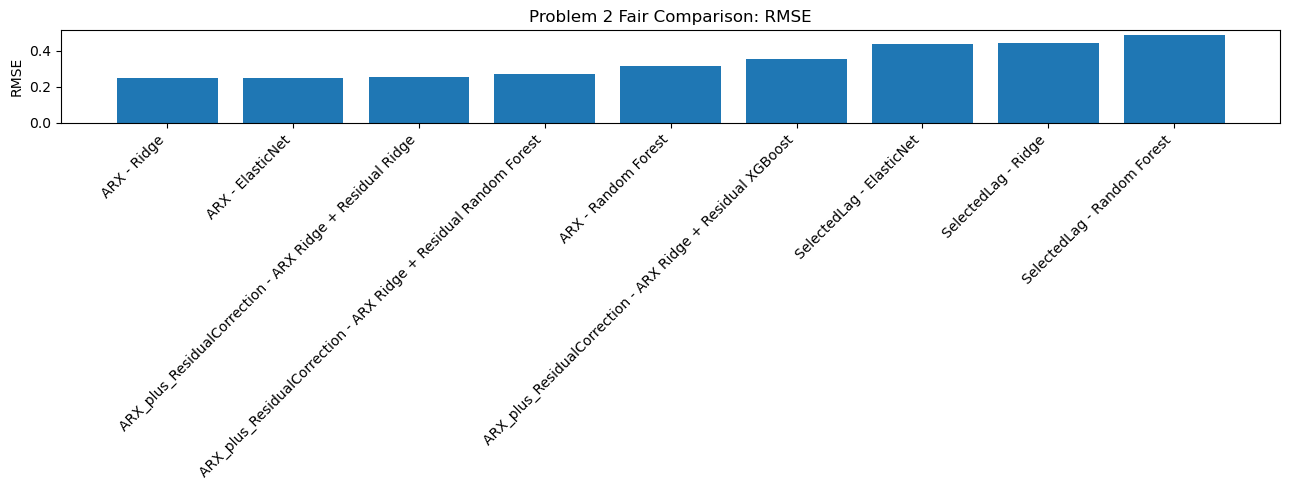

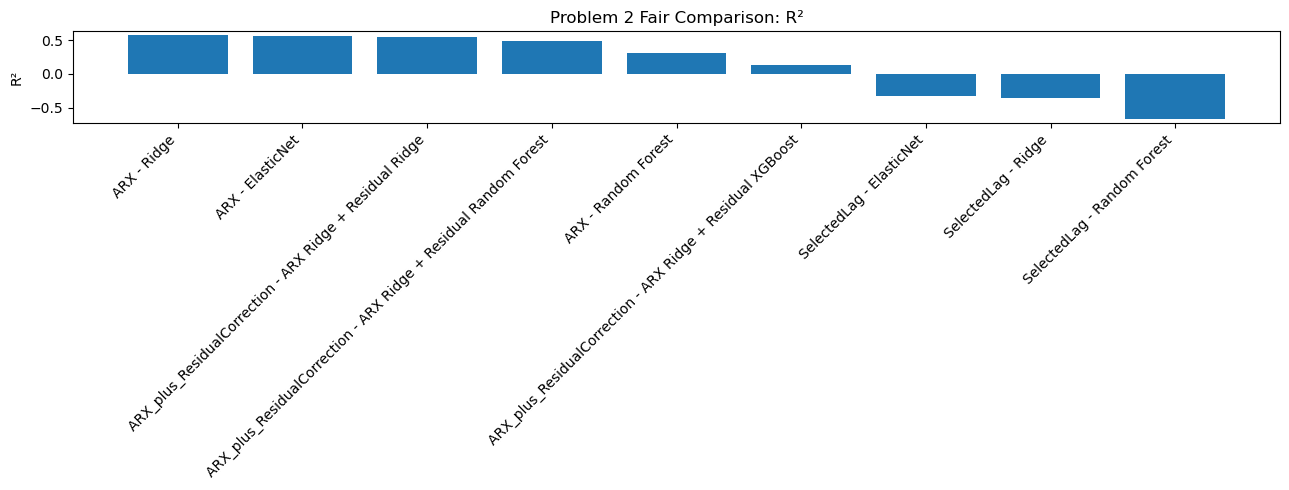

RMSE 对比图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\figures\problem2_arx_residual_rmse_comparison.png
R² 对比图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\figures\problem2_arx_residual_r2_comparison.png


In [19]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " - " + plot_df["model"]

plt.figure(figsize=(13, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 Fair Comparison: RMSE")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_arx_residual_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(13, 5))
plt.bar(plot_df["label"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 Fair Comparison: R²")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_arx_residual_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 对比图已保存：", rmse_fig_path)
print("R² 对比图已保存：", r2_fig_path)


## 20. 可视化：最佳模型预测曲线、散点图和残差图

根据 RMSE 自动选择最佳模型。


最佳模型：


,model_group,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent,base_ARX_test_MAE,base_ARX_test_RMSE,base_ARX_test_R2,residual_train_MAE,residual_train_RMSE,residual_train_R2
0,Direct,ARX,Ridge,8,3821,1639,0.069896,0.248029,0.570617,61.586224,NaN,NaN,NaN,NaN,NaN,NaN


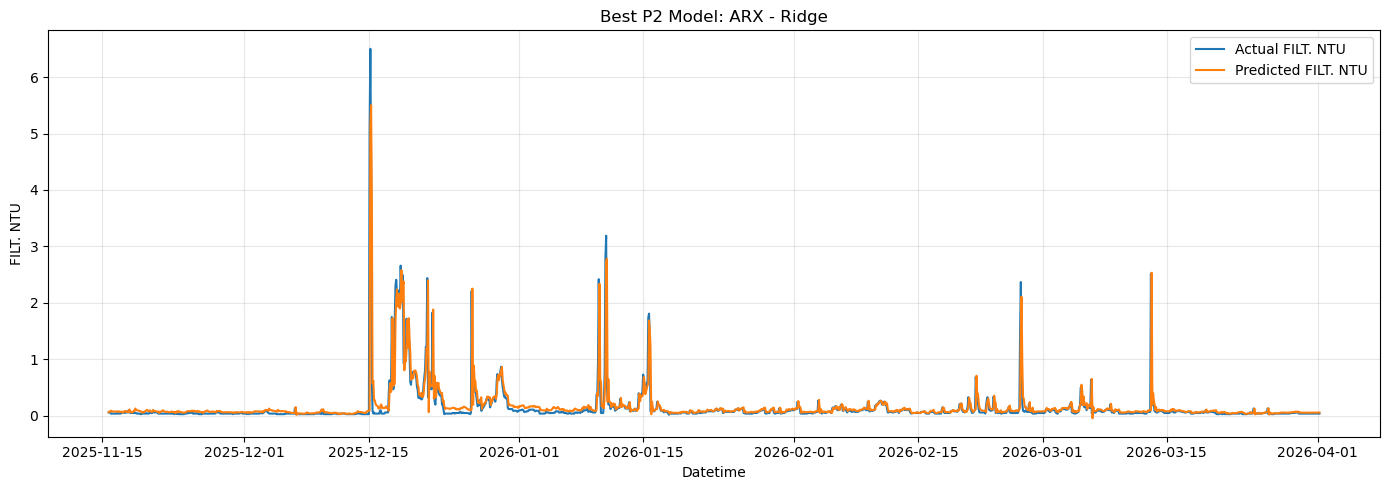

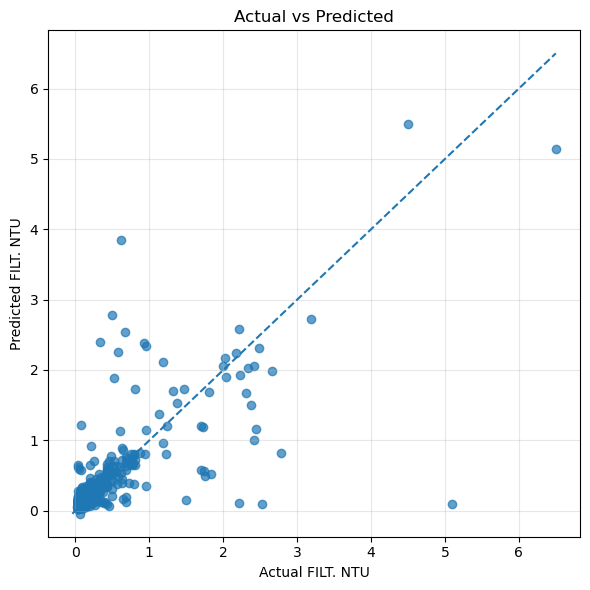

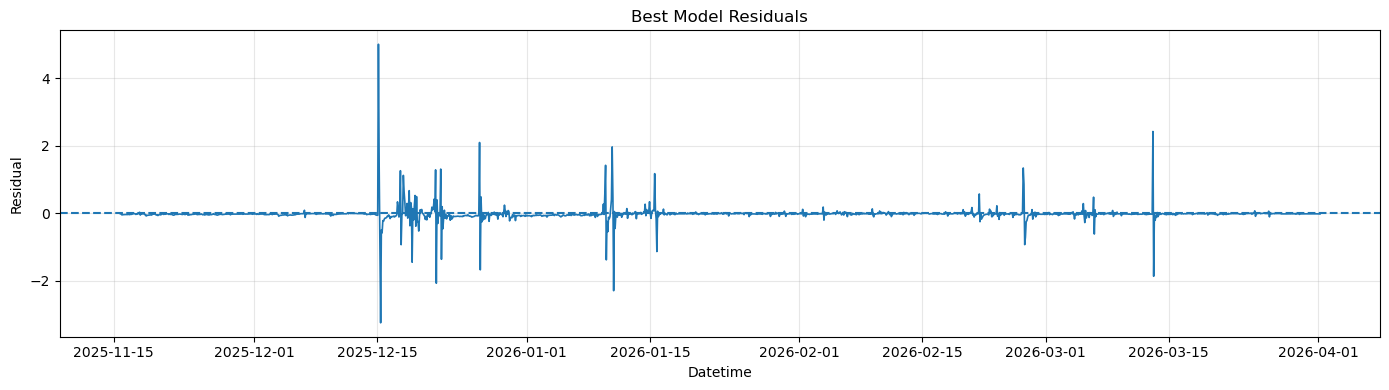

最佳模型预测曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\figures\problem2_best_model_timeseries.png
实际-预测散点图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\figures\problem2_best_model_actual_vs_predicted.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\figures\problem2_best_model_residuals.png


In [20]:
best_row = results_df.iloc[0]
best_model_group = best_row["model_group"]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["model_group"] == best_model_group) &
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU"],
    label="Actual FILT. NTU",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU"],
    label="Predicted FILT. NTU",
    linewidth=1.5,
)
plt.title(f"Best P2 Model: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_best_model_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    best_pred_df["target_FILT_NTU"],
    best_pred_df["predicted_FILT_NTU"],
    alpha=0.7,
)
min_val = min(best_pred_df["target_FILT_NTU"].min(), best_pred_df["predicted_FILT_NTU"].min())
max_val = max(best_pred_df["target_FILT_NTU"].max(), best_pred_df["predicted_FILT_NTU"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual FILT. NTU")
plt.ylabel("Predicted FILT. NTU")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()

avp_fig_path = FIG_DIR / "problem2_best_model_actual_vs_predicted.png"
plt.savefig(avp_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_best_model_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测曲线已保存：", best_ts_fig_path)
print("实际-预测散点图已保存：", avp_fig_path)
print("残差图已保存：", residual_fig_path)


## 21. 输出最终摘要

输出：

```text
problem2_arx_residual_final_summary.xlsx
```

如果 `is_true_enhancement=True`，说明 residual correction 真的比 ARX Ridge 更好。  
如果不是，就应以 ARX Ridge 或最佳 direct model 作为最终模型。


In [21]:
true_enhancement_count = 0
if len(enhancement_judgement_df) > 0 and "is_true_enhancement" in enhancement_judgement_df.columns:
    true_enhancement_count = int(enhancement_judgement_df["is_true_enhancement"].sum())

if true_enhancement_count > 0:
    final_model_decision = "Hybrid residual correction provides a true enhancement over ARX Ridge."
else:
    final_model_decision = "Residual correction does not clearly improve ARX Ridge; use the best model from fair comparison."

final_summary = pd.DataFrame([
    {
        "item": "model_family",
        "value": "ARX + Residual Correction Hybrid Model",
    },
    {
        "item": "target",
        "value": "FILT. NTU",
    },
    {
        "item": "train_test_split",
        "value": f"Time-ordered split, first {int(TRAIN_RATIO * 100)}% train and last {int((1 - TRAIN_RATIO) * 100)}% test.",
    },
    {
        "item": "best_model_group",
        "value": best_model_group,
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "true_residual_enhancement_count",
        "value": true_enhancement_count,
    },
    {
        "item": "final_model_decision",
        "value": final_model_decision,
    },
])

final_summary_path = OUTPUT_DIR / "problem2_arx_residual_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("最终摘要已保存：", final_summary_path)
display(final_summary)


最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_final_summary.xlsx


,item,value
0,model_family,ARX + Residual Correction Hybrid Model
1,target,FILT. NTU
2,train_test_split,"Time-ordered split, first 70% train and last 3..."
3,best_model_group,Direct
4,best_feature_set,ARX
5,best_model,Ridge
6,best_MAE,0.069896
7,best_RMSE,0.248029
8,best_R2,0.570617
9,true_residual_enhancement_count,0


## 22. 论文中可使用的表述

如果 residual correction 有提升，可以写：

```text
为进一步提高动态模型对非线性扰动的刻画能力，本文构建 ARX + Residual Correction 两阶段混合模型。第一阶段使用自回归外生输入模型刻画 FILT. NTU 的动态惯性和主要线性响应，第二阶段以 ARX 残差为目标，利用外生变量的多滞后窗口、短期滚动统计和工艺交互项建立残差修正模型。最终预测由 ARX 主预测和残差修正项相加得到。实验结果显示，残差修正模型在统一测试集上相较 ARX 主模型进一步降低 RMSE 并提高 R²，说明非线性残差修正能够捕捉滤后水浊度中的剩余动态扰动。
```

如果 residual correction 没有提升，则写：

```text
本文进一步尝试 ARX + Residual Correction 两阶段混合模型，以检验外生变量非线性扰动是否能解释 ARX 模型残差。结果表明，残差修正项未在统一测试集上稳定改善 RMSE 和 R²，说明 FILT. NTU 的主要可解释动态信息已被 ARX 自回归项和 selected-lag 外生输入捕捉。因此，最终采用统一测试集下表现最优的模型作为第二问主模型。
```


In [22]:
print("=" * 80)
print("问题二 ARX + Residual Correction Hybrid Model 已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 数据审计：", audit_path)
print("2. selected lag summary：", selected_lag_path)
print("3. 建模数据：", model_data_path)
print("4. 特征集说明：", feature_set_path)
print("5. 模型结果：", results_path)
print("6. 测试集预测：", predictions_path)
print("7. residual enhancement 判断：", enhancement_judgement_path)
print("8. ARX Ridge 参数：", arx_coef_path)
print("9. residual feature importance：", importance_path)
print("10. final summary：", final_summary_path)
print("11. 图片目录：", FIG_DIR)
print("12. 模型目录：", MODEL_DIR)

print("\n模型结果：")
display(results_df)

print("\nResidual enhancement 判断：")
display(enhancement_judgement_df)

print("\n最终摘要：")
display(final_summary)


问题二 ARX + Residual Correction Hybrid Model 已完成。

核心输出文件：
1. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_data_audit.xlsx
2. selected lag summary： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_selected_lag_summary.xlsx
3. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_model_data.xlsx
4. 特征集说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_feature_sets.xlsx
5. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_model_results.xlsx
6. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_test_predictions.xlsx
7. residual enhancement 判断： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_residual_enhancement_judgement.xlsx
8. ARX Ridge 参数： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_resid

,model_group,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent,base_ARX_test_MAE,base_ARX_test_RMSE,base_ARX_test_R2,residual_train_MAE,residual_train_RMSE,residual_train_R2
0,Direct,ARX,Ridge,8,3821,1639,0.069896,0.248029,0.570617,61.586224,NaN,NaN,NaN,NaN,NaN,NaN
1,Direct,ARX,ElasticNet,8,3821,1639,0.067382,0.248851,0.567764,57.441350,NaN,NaN,NaN,NaN,NaN,NaN
2,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual Ridge,75,3821,1639,0.081332,0.254313,0.548582,80.375539,0.069896,0.248029,0.570617,0.062897,0.256208,0.012828
3,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual Random Forest,75,3821,1639,0.088953,0.269419,0.493361,109.701876,0.069896,0.248029,0.570617,0.033934,0.164708,0.592020
4,Direct,ARX,Random Forest,8,3821,1639,0.080792,0.312742,0.317325,43.612385,NaN,NaN,NaN,NaN,NaN,NaN
5,Hybrid,ARX_plus_ResidualCorrection,ARX Ridge + Residual XGBoost,75,3821,1639,0.116066,0.352710,0.131688,178.778626,0.069896,0.248029,0.570617,0.045573,0.133667,0.731308
6,Direct,SelectedLag,ElasticNet,5,3821,1639,0.302195,0.435376,-0.323029,482.538344,NaN,NaN,NaN,NaN,NaN,NaN
7,Direct,SelectedLag,Ridge,5,3821,1639,0.307626,0.440279,-0.352998,491.688472,NaN,NaN,NaN,NaN,NaN,NaN
8,Direct,SelectedLag,Random Forest,5,3821,1639,0.190923,0.488456,-0.665296,232.963983,NaN,NaN,NaN,NaN,NaN,NaN



Residual enhancement 判断：


,baseline_model,hybrid_model,baseline_MAE,hybrid_MAE,MAE_improvement,baseline_RMSE,hybrid_RMSE,RMSE_improvement,baseline_R2,hybrid_R2,R2_improvement,is_true_enhancement
0,ARX Ridge,ARX Ridge + Residual Ridge,0.069896,0.081332,-0.011436,0.248029,0.254313,-0.006285,0.570617,0.548582,-0.022035,False
1,ARX Ridge,ARX Ridge + Residual Random Forest,0.069896,0.088953,-0.019057,0.248029,0.269419,-0.021391,0.570617,0.493361,-0.077256,False
2,ARX Ridge,ARX Ridge + Residual XGBoost,0.069896,0.116066,-0.046170,0.248029,0.352710,-0.104681,0.570617,0.131688,-0.438928,False



最终摘要：


,item,value
0,model_family,ARX + Residual Correction Hybrid Model
1,target,FILT. NTU
2,train_test_split,"Time-ordered split, first 70% train and last 3..."
3,best_model_group,Direct
4,best_feature_set,ARX
5,best_model,Ridge
6,best_MAE,0.069896
7,best_RMSE,0.248029
8,best_R2,0.570617
9,true_residual_enhancement_count,0
